# 3 — Generalized temporal entropies

Notebook 2 gave us a validated, translation-invariant time-step MPO. Rotating the space–time
network by $90^\circ$ turns it into a spatial transfer matrix $\mathcal{E}$ acting on **temporal**
matrix product states (tMPS). Here we compute the quantity that controls the whole transverse
contraction — the **generalized temporal entropy** — and study how it depends on the MPO
construction and on the evolution time.

This notebook is a direct continuation of notebooks 1–2: same model, same $|X+\rangle$ quench, now
viewed in the rotated (temporal) picture.

## From the transfer matrix to the temporal entropy

After the rotation, the two boundary columns of the network are temporal MPS $\langle L|$ and
$|R\rangle$ — the dominant left/right eigenvectors of $\mathcal{E}$. Because $\mathcal{E}$ is
non-Hermitian (the FSM is upper-triangular, notebook 2), the two differ and must be found
independently with the **left–right power method** (`powermethod_lr`). The object that captures the
overlap we actually want, $\langle L|R\rangle$, is the **Reduced Transition Matrix (RTM)**

$$ \mathcal{T}_t \propto |R\rangle\langle L|, $$

a non-Hermitian, unit-trace operator built jointly from the two boundaries (not a density matrix —
that would use $|L\rangle\langle L|$). Its spectrum defines a family of generalized temporal
entropies. The von Neumann member $S_1^{\rm gen}=-\mathrm{Tr}(\mathcal{T}_t\log\mathcal{T}_t)$
requires the full (exponentially large) eigenspectrum; we instead use the **Rényi-2** member,

$$ S_2^{\rm gen}(t) = -\log \mathrm{Tr}(\mathcal{T}_t^2), $$

which needs neither a diagonalization nor a logarithm — two copies of the RTM contracted together —
making it efficient and numerically robust for the **asymmetric** Alcaraz transfer matrix.

Because $\mathcal{T}_t$ is non-Hermitian, $S_2^{\rm gen}$ is generally **complex**; we plot the real
and imaginary parts separately against the normalized temporal cut $t/T$. Its importance is that it
sets the cost of the contraction: at a critical point CFT predicts it grows only **logarithmically**
in time, which is what makes the transverse method efficient (notebooks 6–7).

**The non-conjugating overlap.** Throughout, $\langle L|R\rangle$ is the *bilinear*
`overlap_noconj(L, R)` — never `inner(L, R)`, which would conjugate the bra. This is the single most
common source of wrong transverse results; the library helpers handle it internally.

In [2]:
include("src/thesislib.jl")

plot_panels (generic function with 1 method)

┌ Warning: ProgressMeter by default refresh meters with additional information in IJulia via `IJulia.clear_output`, which clears all outputs in the cell. 
│  - To prevent this behaviour, do `ProgressMeter.ijulia_behavior(:append)`. 
│  - To disable this warning message, do `ProgressMeter.ijulia_behavior(:clear)`.
└ @ ProgressMeter ~/.julia/packages/ProgressMeter/N660J/src/ProgressMeter.jl:607
[PM LR|RTM] L=34, cutoff=1.0e-12, maxdim=256, normalize=overlap)   4%  ETA: 0:05:41 (44.19 ms/it)
   Info: [290]  chi=6 | ds=3.0711257259508074e-6 | <R|Rprev> = -1.4451323376492542e-6[ Info: PM Converged after 293 steps | ds=9.898357092863463e-7 | chi=6)


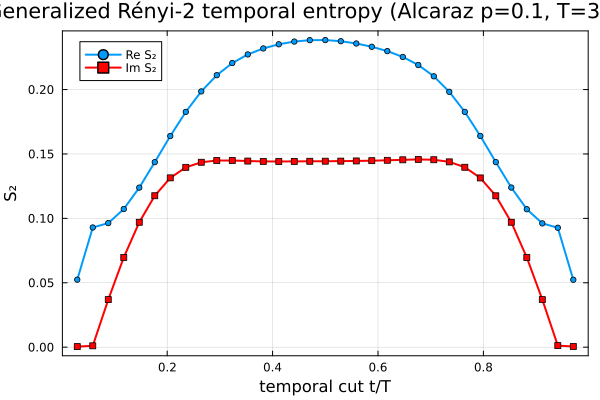

In [ ]:
# A temporal-entropy run is one call to the library driver. It builds the forward tMPO for the
# given model + MPO scheme, runs powermethod_lr from a random seed (anti Z2-trap), and returns
# the Rényi-2 profile S2(t) per internal bond. nbeta = 2β0/dt cooling sites regularize the UV.
mp = AlcarazParams(lambda=1.0, p=0.1)
res = compute_entropies(mp, 3.0; scheme=AlcarazVD2(), dt=0.1, nbeta=4, maxdim=256)

plot(res.bonds ./ (length(res.bonds)+1), res.re; label="Re S₂", lw=2, marker=:circle, ms=3,
     xlabel="temporal cut t/T", ylabel="S₂", framestyle=:box, grid=true,
     title="Generalized Rényi-2 temporal entropy (Alcaraz p=0.1, T=3, VD2)")
plot!(res.bonds ./ (length(res.bonds)+1), res.im; label="Im S₂", lw=2, marker=:square, ms=3, color=:red)

## Growth with time and the conformal dome

Sweeping the final time $T$ traces out the entropy profile as a function of the temporal cut. At a
critical point the profile takes the universal **chord** shape
$\propto \log[(2T/\pi)\sin(\pi t/T)]$, peaked at mid-cut and growing logarithmically with $T$. The
library's `plot_entropy_profiles` overlays several $T$ in one figure. (This is a real power-method
run per time, so it is moderately heavy — start with a few times.)

┌ Warning: ProgressMeter by default refresh meters with additional information in IJulia via `IJulia.clear_output`, which clears all outputs in the cell. 
│  - To prevent this behaviour, do `ProgressMeter.ijulia_behavior(:append)`. 
│  - To disable this warning message, do `ProgressMeter.ijulia_behavior(:clear)`.
└ @ ProgressMeter ~/.julia/packages/ProgressMeter/N660J/src/ProgressMeter.jl:607
[PM LR|RTM] L=69, cutoff=1.0e-12, maxdim=256, normalize=overlap)  67%  ETA: 0:07:11 ( 0.16  s/it)
   Info: [5340]  chi=11 | ds=0.0004145352822072512 | <R|Rprev> = -1.8067769819790878e-6┌ Warning: PM Stuck after 2001/5341 steps | ds=0.00038274808287086515 | chi=11)
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/power_method/pm.jl:151
entropy profiles (AlcarazVD2)... 100%|███████████████████| Time: 0:38:11


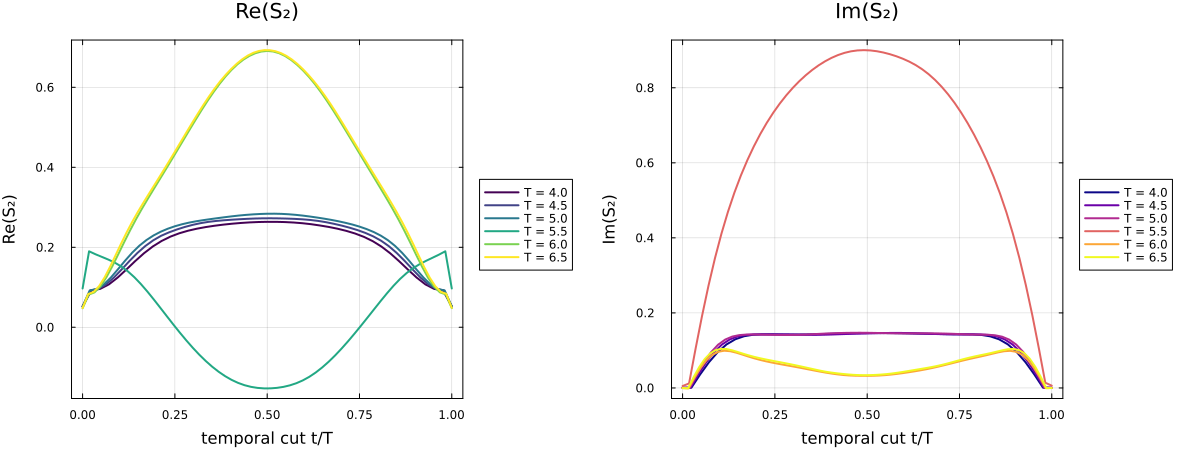

In [2]:
# Single-vector power method (the DEFAULT, use_block_pm=false): one powermethod_lr run per T.
# Watch the profiles: clean conformal domes at small T, but they fall apart once T ≳ 5.
mp = AlcarazParams(lambda=1.0, p=0.1)
plot_entropy_profiles(mp, [4.0, 4.5, 5.0, 5.5, 6.0, 6.5]; scheme=AlcarazVD2(), dt=0.1, nbeta=4, maxdim=256)

## The power method stops converging: the entanglement barrier strikes back

The profiles above are clean conformal domes at small $T$ but **fall apart for $T\gtrsim5$**. This
is not a physical effect — it is a *convergence failure of the single-vector power method*. As $T$
grows the two leading transfer-matrix eigenvalues approach each other (the **gap closes**, quantified
in notebook 5); `powermethod_lr` then cannot separate the dominant eigenvector from the subdominant
one, stalls before `eps_converged`, and returns a contaminated $(\langle L|,|R\rangle)$ pair whose
Rényi-2 profile no longer follows the chord. Bumping `itermax`/`stuck_after` only delays the wall.
**The gap closing — i.e. the entanglement barrier of notebook 1 — is exactly what manifests here.**

There are two ways forward, and they trade off against each other:

1. **Track only the leading eigenvalue $\lambda_0$.** A subspace (block) method gives $\lambda_0(T)$
   robustly straight through the degeneracy. This is the route of notebooks 5 and 7 (Loschmidt rate,
   Eq. 3 central charge), but it **sacrifices the entropy *profile*** — an eigenvalue is not an
   eigenvector.

2. **Use the block power method to keep the eigenvectors.** `block_transfer_eigs` carries $k$ left
   and right Ritz vectors and de-mixes them each iteration, so it stays well-behaved at the gap
   closing and still returns a bi-orthonormal leading $(\langle L|,|R\rangle)$ pair — enough to
   rebuild the entropy profile. It is heavier, and deep inside the barrier the recovered vectors can
   still be mildly contaminated by eigenvector mixing, but it pushes the usable window to noticeably
   larger $T$.

Option 2 is now available directly from the library: `compute_entropies(...; use_block_pm=true)`
(and the matching `plot_entropy_profiles(...; use_block_pm=true)`). The next cell reruns the *same*
sweep through the block method.

[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=730|"S=1/2,Site") <-> (dim=2|id=730|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=57|"Link,l=1") <-> (dim=7|id=881|"Link,l=2"), normdiff = 1.1566412865695994
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=508|"S=1/2,Site") <-> (dim=2|id=508|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=31|"Link,l=1") <-> (di

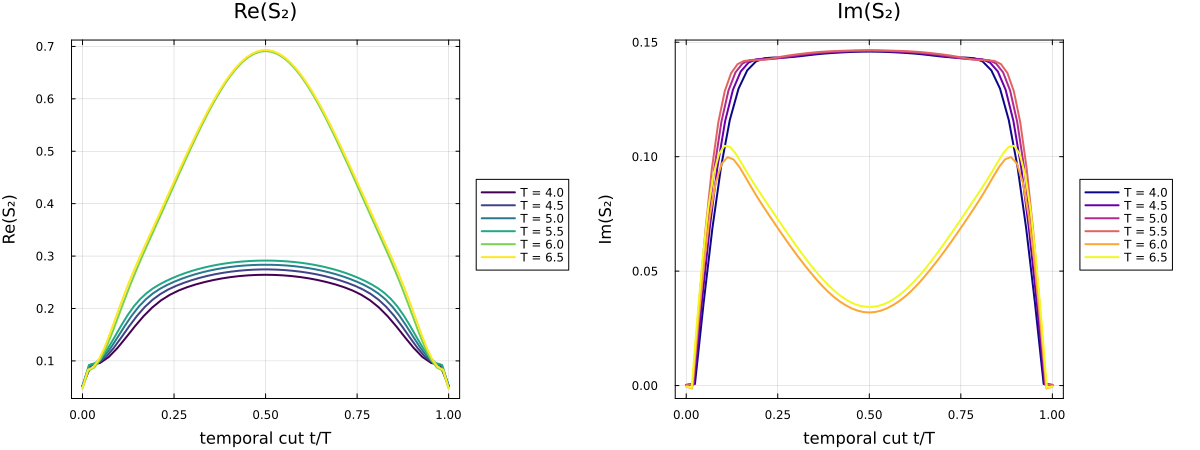

In [3]:
# Same sweep through the block power method (use_block_pm=true): the domes survive past T=5.
# Heavier than the single-vector sweep, but the entanglement barrier is pushed to larger T.
mp = AlcarazParams(lambda=1.0, p=0.1)
plot_entropy_profiles(mp, [4.0, 4.5, 5.0, 5.5, 6.0, 6.5]; scheme=AlcarazVD2(), dt=0.1, nbeta=4,
                      maxdim=256, use_block_pm=true, k_block=2)

┌ Warning: ProgressMeter by default refresh meters with additional information in IJulia via `IJulia.clear_output`, which clears all outputs in the cell. 
│  - To prevent this behaviour, do `ProgressMeter.ijulia_behavior(:append)`. 
│  - To disable this warning message, do `ProgressMeter.ijulia_behavior(:clear)`.
└ @ ProgressMeter ~/.julia/packages/ProgressMeter/N660J/src/ProgressMeter.jl:607
[PM LR|RTM] L=59, cutoff=1.0e-12, maxdim=256, normalize=overlap)  28%  ETA: 0:08:49 (92.46 ms/it)
   Info: [2276]  chi=9 | ds=0.019199275680008787 | <R|Rprev> = -0.001397092351797895┌ Warning: PM Stuck after 2001/2277 steps | ds=0.018741195693735335 | chi=9)
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/power_method/pm.jl:151
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=596|"S=1/2,Site") <-> (dim=2|id=596|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUt

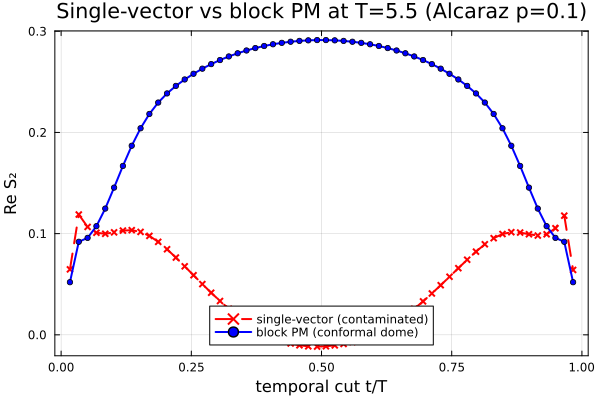

In [4]:
# Head-to-head at T=5.5, just past where the single-vector method breaks.
mp = AlcarazParams(lambda=1.0, p=0.1); T = 5.5
r1 = compute_entropies(mp, T; scheme=AlcarazVD2(), dt=0.1, nbeta=4, maxdim=256, use_block_pm=false)
r2 = compute_entropies(mp, T; scheme=AlcarazVD2(), dt=0.1, nbeta=4, maxdim=256, use_block_pm=true)
x1 = r1.bonds ./ (length(r1.bonds)+1); x2 = r2.bonds ./ (length(r2.bonds)+1)
plt = plot(xlabel="temporal cut t/T", ylabel="Re S₂", framestyle=:box, grid=true, legend=:bottom,
           title="Single-vector vs block PM at T=$T (Alcaraz p=0.1)")
plot!(plt, x1, r1.re; label="single-vector (contaminated)", lw=2, ls=:dash, color=:red, marker=:x, ms=3)
plot!(plt, x2, r2.re; label="block PM (conformal dome)",    lw=2, color=:blue, marker=:circle, ms=3)

## MPO scheme dependence: VD2 vs WII

The temporal entropy is computed from the *same* network regardless of how $U(\delta t)$ was built,
so switching the exponentiation kernel isolates its effect. From notebook 2 we expect VD2
(unconditionally 2nd order) to be the trustworthy choice for this NNN model and WII (genuinely 1st
order here) to deviate, especially at larger $T$ where the temporal chain is long. The cell below
compares them at a fixed time.

┌ Warning: ProgressMeter by default refresh meters with additional information in IJulia via `IJulia.clear_output`, which clears all outputs in the cell. 
│  - To prevent this behaviour, do `ProgressMeter.ijulia_behavior(:append)`. 
│  - To disable this warning message, do `ProgressMeter.ijulia_behavior(:clear)`.
└ @ ProgressMeter ~/.julia/packages/ProgressMeter/N660J/src/ProgressMeter.jl:607
[PM LR|RTM] L=34, cutoff=1.0e-12, maxdim=256, normalize=overlap)   2%  ETA: 0:02:26 (18.63 ms/it)
   Info: [185]  chi=6 | ds=1.830060906704567e-6 | <R|Rprev> = -4.5035254984377207e-7[ Info: PM Converged after 193 steps | ds=9.608666547977762e-7 | chi=6)


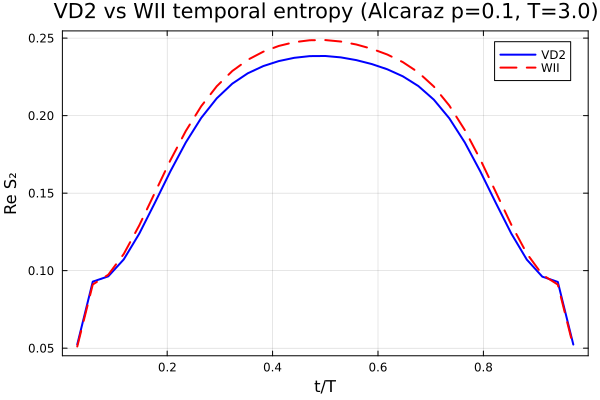

In [5]:
# Compare the entropy profile under VD2 vs WII at a fixed final time.
mp = AlcarazParams(lambda=1.0, p=0.1)
T  = 3.0
rV = compute_entropies(mp, T; scheme=AlcarazVD2(), dt=0.1, nbeta=4, maxdim=256)
rW = compute_entropies(mp, T; scheme=AlcarazWII(), dt=0.1, nbeta=4, maxdim=256)
xV = rV.bonds ./ (length(rV.bonds)+1); xW = rW.bonds ./ (length(rW.bonds)+1)
plt = plot(xlabel="t/T", ylabel="Re S₂", framestyle=:box, grid=true,
           title="VD2 vs WII temporal entropy (Alcaraz p=0.1, T=$T)")
plot!(plt, xV, rV.re; label="VD2", lw=2, color=:blue)
plot!(plt, xW, rW.re; label="WII", lw=2, ls=:dash, color=:red)

## Takeaways

- The generalized **Rényi-2** temporal entropy $S_2^{\rm gen}(t)=-\log\mathrm{Tr}(\mathcal{T}_t^2)$
  is the cost-controlling observable of the transverse method, computed from the RTM built out of
  the two power-method boundaries (always via the non-conjugating overlap).
- Its profile has the conformal chord shape and grows logarithmically with $T$ — the signature we
  quantify against CFT in notebooks 6–7.
- **The single-vector power method stops converging once the transfer-matrix gap closes** ($T\gtrsim5$
  for $p=0.1$): the entropy profile then peels off the chord. This is the entanglement barrier of
  notebook 1, seen in the rotated picture.
- The **block power method** (`use_block_pm=true`) keeps the left/right eigenvectors well-separated
  through the degeneracy and recovers the conformal dome to larger $T$. The alternative — tracking
  only the eigenvalue $\lambda_0$ — is robust but discards the profile (notebooks 5, 7).
- VD2 is the reliable kernel for the NNN model; WII deviates as the temporal chain lengthens.

Two ingredients are still needed before we can read a *central charge* off these curves: the
equilibrium value of $c$ as a target (notebook 4), and a converged, well-understood transfer-matrix
spectrum (notebook 5).

## Appendix: dependence on the Trotter step $\delta t$

The block PM pushes the entanglement-barrier onset $T_{\rm crit}$ — the time beyond which the power
method stops converging and the dome breaks — to larger $T$. A natural question is whether
$T_{\rm crit}$ is a **physical** time or partly a **discretization** artifact: does it move when we
refine the Trotter step $\delta t$?

Here we repeat the entropy sweep at $\delta t=0.05$ and compare to the $\delta t=0.1$ figures above,
at the **same physical times** $T$. One subtlety: to hold the UV regulator $\beta_0=0.2$ fixed we
need $N_\beta = 2\beta_0/\delta t$ cooling sites, so $\delta t=0.05 \Rightarrow$ `nbeta=8` (vs
`nbeta=4` at $\delta t=0.1$). Smaller $\delta t$ also means **twice as many temporal sites** for the
same $T$ (a longer tMPS), so these runs are correspondingly heavier.

*(All cells below are additive — they do not modify the runs above.)*

### Single-vector PM: does the barrier move with $\delta t$?

First the cheap single-vector method. Compare the figure below ($\delta t=0.05$) to the
$\delta t=0.1$ single-vector sweep earlier in the notebook: if the dome breaks at the same physical
$T$, the barrier is physical; if $\delta t=0.05$ pushes the break to a different $T$, the onset is
sensitive to the discretization.

In [ ]:
# Single-vector PM at δt=0.05 (nbeta=8 keeps β0=0.2). Same T list as the δt=0.1 sweep above.
mp = AlcarazParams(lambda=1.0, p=0.1)
plot_entropy_profiles(mp, [4.0, 4.5, 5.0, 5.5, 6.0, 6.5]; scheme=AlcarazVD2(), dt=0.05, nbeta=8,
                      maxdim=256, use_block_pm=false)

┌ Warning: ProgressMeter by default refresh meters with additional information in IJulia via `IJulia.clear_output`, which clears all outputs in the cell. 
│  - To prevent this behaviour, do `ProgressMeter.ijulia_behavior(:append)`. 
│  - To disable this warning message, do `ProgressMeter.ijulia_behavior(:clear)`.
└ @ ProgressMeter ~/.julia/packages/ProgressMeter/N660J/src/ProgressMeter.jl:607
[PM LR|RTM] L=118, cutoff=1.0e-12, maxdim=256, normalize=overlap)   3%  ETA: 2:06:18 ( 0.98  s/it)
   Info: [277]  chi=8 | ds=0.026358566255374333 | <R|Rprev> = -0.0009417074800489532

In [ ]:
# Quantitative T_crit: single-vector PM convergence vs (δt, T). reason ≠ "converged" ⇒ barrier hit.
# The maxχ column also shows the *actual* bond dim the problem reaches (input to notebook 3.5).
using Printf
Tgrid = [4.0, 4.5, 5.0, 5.5, 6.0, 6.5]
@printf("%-6s %-6s %-12s %-12s %-8s\n","δt","T","reason","final_ds","maxχ")
for (dt_, nb_) in [(0.1, 4), (0.05, 8)]
    for T in Tgrid
        r = run_pm_diagnosed(T; p=0.1, lambda=1.0, dt=dt_, maxdim=256, cutoff=1e-12,
                             eps_converged=1e-6, nbeta=nb_, MPO_alg="VD2",
                             itermax=5000, stuck_after=1000)
        maxchi = isempty(r.chi_hist) ? 0 : maximum(r.chi_hist)
        @printf("%-6.2f %-6.1f %-12s %-12.2e %-8d\n", dt_, T, r.reason, r.final_ds, maxchi)
        GC.gc()
    end
end

**How to read it.** $T_{\rm crit}$ is the first $T$ whose `reason` is no longer `"converged"`.
Compare the two $\delta t$ blocks: an (approximately) **unchanged** $T_{\rm crit}$ means the barrier
is a physical time scale (the eigenvalue gap closes at a fixed physical $T$); a **shifted**
$T_{\rm crit}$ means the discretization itself influences convergence (e.g. the longer $\delta t=0.05$
chain is harder, or reduced Trotter error cleans the spectrum). The `maxχ` column is a preview of
notebook 3.5: if it stays well below the `maxdim=256` cap, the cap is oversized and the block PM can
be made much cheaper.

### Block PM at $\delta t=0.05$ (heavy — run last)

Finally the same $\delta t=0.05$, `nbeta=8` sweep through the **block** power method, to compare its
barrier onset against the $\delta t=0.1$ block-PM figure above. This is the most expensive cell in
the notebook (block PM on a 2×-longer tMPS); run it last.

In [ ]:
# HEAVY: block PM at δt=0.05 (nbeta=8). Compare the break point to the δt=0.1 block-PM figure above.
mp = AlcarazParams(lambda=1.0, p=0.1)
plot_entropy_profiles(mp, [4.0, 4.5, 5.0, 5.5, 6.0, 6.5]; scheme=AlcarazVD2(), dt=0.05, nbeta=8,
                      maxdim=256, use_block_pm=true, k_block=2)